<a href="https://colab.research.google.com/github/jess22jess/SIMULACI-IN-I/blob/main/PROYECTO_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# SIMULACIÓN I
---
ARCOS GUTIÉRREZ JESSICA BEATRIZ
____________________________________________


*   Línea de Espera 2 Servidores (serie y paralelo)
*   Técnicas de reducción de varianza: Variables Antitéticas
*   Técnicas de Remustreo: Bootstrap y Jackknife

---

*  LÍNEA DE ESPERA 2 SERVIDORES

**Sistema en serie**

En un sistema de cola en serie, los clientes llegan de acuerdo con un proceso Poisson con tasa λ. Cada cliente debe ser atendido primero por el servidor 1 y, al terminar, pasa al servidor 2. Después de ser atendido en el servidor 2, el cliente sale del sistema.

Los tiempos de servicio en cada servidor siguen distribuciones exponenciales con tasas μ₁ y μ₂ respectivamente.

Definimos las siguientes variables de interés:

W₁: tiempo que un cliente pasa en el servidor 1 (incluye espera + servicio)

W₂: tiempo que un cliente pasa en el servidor 2 (incluye espera + servicio)

W = W₁ + W₂: tiempo total que un cliente pasa en el sistema

El estimador del tiempo promedio en el sistema es:


$\hat{W} = \frac{1}{n} \sum_{i=1}^{n} (D_i - A_{1i})$


Donde:

A₁ᵢ: hora de llegada del cliente i al servidor 1

Dᵢ: hora de salida del cliente i del sistema

La simulación avanza mediante eventos. En cada paso, el tiempo avanza al siguiente evento entre:

Llegada (tₐ): un nuevo cliente llega al sistema

Fin de servicio en servidor 1 (t₁): un cliente termina en S1 y pasa a S2

Fin de servicio en servidor 2 (t₂): un cliente termina en S2 y sale del sistema

**Sistema en paralelo**

En un sistema de cola en paralelo, los clientes llegan de acuerdo con un proceso Poisson con tasa λ. Al llegar, un cliente es atendido por el servidor 1 si está libre, o por el servidor 2 si el servidor 1 está ocupado. Si ambos están ocupados, el cliente se forma en una cola común.

Los tiempos de servicio en cada servidor siguen distribuciones exponenciales con tasas μ₁ y μ₂ respectivamente.

A diferencia del sistema en serie, en paralelo:

Los clientes no pasan por ambos servidores, solo por uno

Hay una sola cola de espera (no dos)

Los clientes pueden salir en diferente orden al que llegaron

El estimador del tiempo promedio en el sistema es:

$\hat{W} = \frac{1}{n} \sum_{i=1}^{n} (D_i - A_{i})$

Donde:

Aᵢ: hora de llegada del cliente i al sistema

Dᵢ: hora de salida del cliente i del sistema

Definimos también:

C₁: número de clientes atendidos por el servidor 1

C₂: número de clientes atendidos por el servidor 2

Importamos las librerías las cuáles hemos usado a lo largo del semestre

In [38]:
import numpy as np
import random as r
import matplotlib.pyplot as plt

Con esta función lo que se hace es generar el tiempo entre llegadas usando la transformada inversa

In [39]:
def tiempo_llegada(lam):
    u = r.random()
    return -np.log(u) / lam

Generamos el tiempo de servicio para el servidor 1

In [40]:
def tiempo_servicio1(mu1):
    u = r.random()
    return -np.log(u) / mu1

Generamos el tiempo de servicio para el servidor 2

In [41]:
def tiempo_servicio2(mu2):
    u = r.random()
    return -np.log(u) / mu2

Defunimos *lam* como la tasa de llamadas, *mu1* como la tasa de servicio servidor 1, y de igual manera para *mu2* como la tasa de servicio servidor 2. *T* es el tiempo se simulación.

In [42]:
def simular_serie(lam, mu1, mu2, T):
    # Inicialización
    t = 0.0
    NA = 0
    ND = 0
    n1 = 0
    n2 = 0

    A1 = []
    A2 = []
    D = []

    tA = tiempo_llegada(lam)
    t1 = float("inf")
    t2 = float("inf")

    cola1 = []
    cola2 = []
    cliente = 0

    while True:
        # CASO 1: Llegada
        if tA <= t1 and tA <= t2 and tA <= T:
            t = tA
            cliente += 1
            NA += 1
            A1.append(t)
            tA = t + tiempo_llegada(lam)

            if n1 == 0:
                n1 = 1
                t1 = t + tiempo_servicio1(mu1)
            else:
                cola1.append(cliente)
                n1 += 1

        # CASO 2: Fin servicio 1
        elif t1 <= tA and t1 <= t2 and t1 <= T:
            t = t1
            A2.append(t)
            n1 -= 1

            if n1 == 0:
                t1 = float("inf")
            else:
                cola1.pop(0)
                t1 = t + tiempo_servicio1(mu1)

            if n2 == 0:
                n2 = 1
                t2 = t + tiempo_servicio2(mu2)
            else:
                cola2.append(cliente)
                n2 += 1

        # CASO 3: Fin servicio 2
        elif t2 <= tA and t2 <= t1 and t2 <= T:
            t = t2
            ND += 1
            D.append(t)
            n2 -= 1

            if n2 == 0:
                t2 = float("inf")
            else:
                cola2.pop(0)
                t2 = t + tiempo_servicio2(mu2)

        # CASO 4: Fin
        else:
            Tp = max(t - T, 0)
            break

    # Resultados
    tiempos = []
    for i in range(len(A1)):
        if i < len(D):
            tiempos.append(D[i] - A1[i])

    prom = sum(tiempos) / len(tiempos) if tiempos else 0

    return {
        "NA": NA,
        "ND": ND,
        "promedio": prom,
        "Tp": Tp
    }

In [43]:
lam = 4.0
mu1 = 6.0
mu2 = 5.0
T = 10.0
N = 1000

In [44]:
promedios = []
Tp_todos = []

In [45]:
for i in range(N):
    resultado = simular_serie(lam, mu1, mu2, T)
    promedios.append(resultado["promedio"])
    Tp_todos.append(resultado["Tp"])

In [46]:
print(f"Tiempo promedio en sistema: {np.mean(promedios):.4f}")
print(f"Tiempo posterior a T: {np.mean(Tp_todos):.4f}")

Tiempo promedio en sistema: 0.9881
Tiempo posterior a T: 0.0000


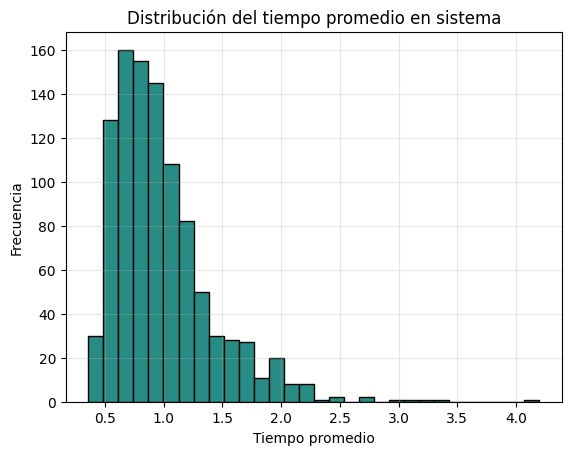

In [47]:
# Gráfica
plt.hist(promedios, bins=30, edgecolor='black', color='#278C83')
plt.xlabel('Tiempo promedio')
plt.ylabel('Frecuencia')
plt.title('Distribución del tiempo promedio en sistema')
plt.grid(True, alpha=0.3)
plt.show()

En Paralelo

In [48]:
def simular_paralelo(lam, mu1, mu2, T):
    # Inicialización
    t = 0.0
    NA = 0
    ND = 0
    n = 0

    A = []
    D = []
    cola = []

    serv1 = 0
    serv2 = 0

    tA = tiempo_llegada(lam)
    t1 = float("inf")
    t2 = float("inf")

    cliente = 0

    while True:
        # CASO 1: Llegada
        if tA <= t1 and tA <= t2 and tA <= T:
            t = tA
            cliente += 1
            NA += 1
            A.append(t)
            tA = t + tiempo_llegada(lam)

            if serv1 == 0:
                serv1 = cliente
                t1 = t + tiempo_servicio1(mu1)
                n += 1
            elif serv2 == 0:
                serv2 = cliente
                t2 = t + tiempo_servicio2(mu2)
                n += 1
            else:
                cola.append(cliente)
                n += 1

        # CASO 2: Fin servicio 1
        elif t1 <= tA and t1 <= t2 and t1 <= T:
            t = t1
            ND += 1
            D.append(t)

            if cola:
                serv1 = cola.pop(0)
                t1 = t + tiempo_servicio1(mu1)
            else:
                serv1 = 0
                t1 = float("inf")
                n -= 1

        # CASO 3: Fin servicio 2
        elif t2 <= tA and t2 <= t1 and t2 <= T:
            t = t2
            ND += 1
            D.append(t)

            if cola:
                serv2 = cola.pop(0)
                t2 = t + tiempo_servicio2(mu2)
            else:
                serv2 = 0
                t2 = float("inf")
                n -= 1

        # CASO 4: Fin
        else:
            Tp = max(t - T, 0)
            break

    tiempos = []
    for i in range(len(A)):
        if i < len(D):
            tiempos.append(D[i] - A[i])

    prom = sum(tiempos) / len(tiempos) if tiempos else 0

    return {
        "NA": NA,
        "ND": ND,
        "promedio": prom,
        "Tp": Tp
    }

Le damos valores a nuestras variables

In [49]:
lam = 4.0
mu1 = 6.0
mu2 = 5.0
T = 10.0
num_ejecuciones = 1000

Creamos listas para guardar los resultados de cada ejecución

In [50]:
resultados = []
promedios_sistema = []
Tp_todos = []

Usamos un for para ejecutar la simulación N veces

In [51]:
for i in range(num_ejecuciones):
    resultado = simular_paralelo(lam, mu1, mu2, T)
    resultados.append(resultado)
    promedios_sistema.append(resultado["promedio"])
    Tp_todos.append(resultado["Tp"])

Calculamos el promedio de todos los tiempos promedio obtenidos y el promedio de todos los tiempos extra después de T

In [52]:
promedio_final_sistema = sum(promedios_sistema) / len(promedios_sistema)
promedio_final_Tp = sum(Tp_todos) / len(Tp_todos)

Aquí vemos los resultados

In [53]:
print(f"Tiempo promedio en sistema: {promedio_final_sistema:.4f}")
print(f"Tiempo posterior a T promedio: {promedio_final_Tp:.4f}")

Tiempo promedio en sistema: 0.1979
Tiempo posterior a T promedio: 0.0000


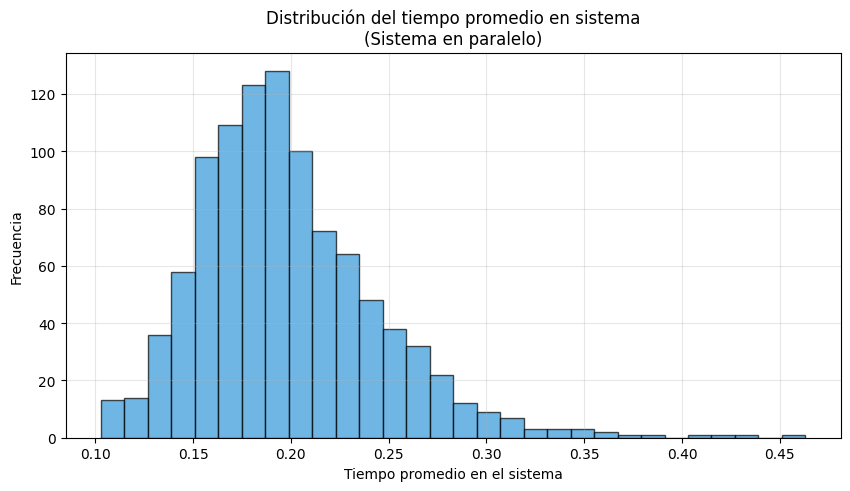

In [54]:
plt.figure(figsize=(10, 5))
plt.hist(promedios_sistema, bins=30, edgecolor='black', color='#3498DB', alpha=0.7)
plt.xlabel('Tiempo promedio en el sistema')
plt.ylabel('Frecuencia')
plt.title('Distribución del tiempo promedio en sistema\n(Sistema en paralelo)')
plt.grid(True, alpha=0.3)
plt.show()

* TÉCNICAS DE REDUCCIÓN DE VARIANZA: VARIABLES ANTIÉTICAS

---
Si U ~ Uniform(0,1), entonces 1-U también ~ Uniform(0,1)

Para estimar θ = ∫₀¹ f(x) dx, definimos:
  Y₁ = f(U)
 Y₂ = f(1-U)

Notamos que:
  E[Y₁] = E[Y₂] = θ

El estimador antitético es:
  θ̂ = (Y₁ + Y₂) / 2

La varianza de este estimador es:
  Var(θ̂) = (Var(Y₁) + Var(Y₂) + 2Cov(Y₁,Y₂)) / 4

Si f es monótona, entonces Y₁ y Y₂ están correlacionadas negativamente,
  por lo que Cov(Y₁,Y₂) < 0, reduciendo la varianza.

  ---


Definimos la función a integrar

In [55]:
def f(x):
    return 1/(1+x)

Probamos la función con un valor 0.5

In [56]:
f(0.5)

0.6666666666666666

MÉTODO MONTE CARLO SIMPLE

Se hace una estimación de la integral usando Monte Carlo simple, después se generan N números aleatorios U ~ Uniform(0,1) y se calcula el promedio de f(U)

In [57]:
def mc1(f,N):
    s=0
    for i in range (N):
        U = r.random()
        s += f(U)
    return s/N

Probamos mc1 con 100 repeticiones

In [58]:
l = []
for i in range(100):
    M = mc1(f,1000)
    l.append(M)
print(np.mean(l))
print(np.var(l))

0.6932512352990446
1.707789887095648e-05


 MÉTODO CON VARIABLE ANTITÉTICA

 Estimación usando solo la variable antitética 1-U

In [59]:
def mc2(f,N):
    s=0
    for i in range (N):
        U = r.random()
        s += f(1-U)  # Usamos 1-U en lugar de U
    return s/N

Probamos mc2

In [60]:
l = []
for i in range(100):
    M = mc2(f,1000)
    l.append(M)
print(np.mean(l))
print(np.var(l))

0.6932277379844439
1.656613179630071e-05


MÉTODO COMPLETO CON VARIABLES ANTITÉTICAS

 Para cada U, usamos el par (U, 1-U) y promediamos.
Esto reduce la varianza.

In [61]:
def mc(f,N):
    s=0
    for i in range (N):
        U = r.random()
        # Promediamos f(U) y f(1-U) para cada par
        s += (f(U) + f(1-U))/2
    return s/N

Probamos el método completo

In [62]:
l = []
for i in range(100):
    M = mc(f,1000)
    l.append(M)
print(np.mean(l))
print(np.var(l))

0.6931198306793681
5.137945900283282e-07


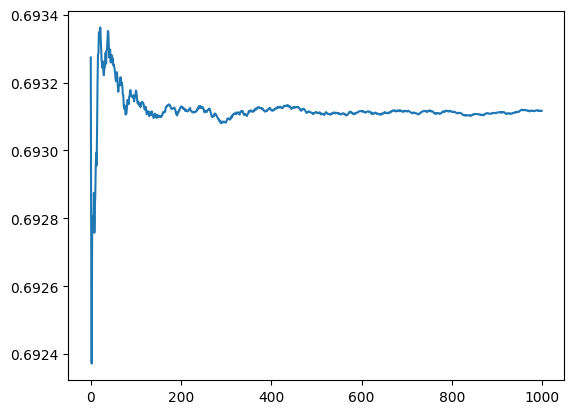

In [63]:
# Calculamos la convergencia acumulada
l = []
hw=[]
for i in range(1000):
    M = mc(f,1000)
    l.append(M)
    No= np.mean(l)
    hw.append(No)
plt.plot(hw)


In [64]:
#error porcentual
(2.2856276241609895e-05-4.803227014607017e-07)/2.2856276241609895e-05

0.9789850850425813

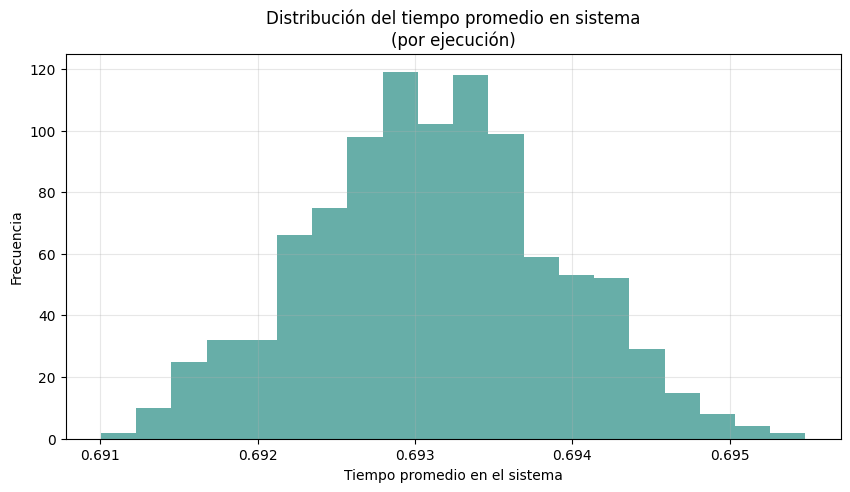

In [65]:
plt.figure(figsize=(10, 5))
plt.hist(l, bins=20, color='#278C83', alpha=0.7)
plt.xlabel('Tiempo promedio en el sistema')
plt.ylabel('Frecuencia')
plt.title('Distribución del tiempo promedio en sistema\n(por ejecución)')
plt.grid(True, alpha=0.3)

plt.show()

*  TÉCNICAS DE REMUESTREO: BOOTSTRAP Y JACKKNIFE
---


**Jackknife**

Tenemos una muestra de $n$ datos. En esta técnica eliminamos uno de los datos para obtener $n$ muestras de tamaño $n-1$. Para cada muestra calculamos el estadístico $\Theta_i$ y luego obtenemos el promedio del Jackknife:

$$\bar{\Theta}_{JK} = \frac{1}{n} \sum_{i=1}^n \Theta_i$$

La varianza:

$$Var_{JK} = \frac{n-1}{n} \sum_{i=1}^n (\Theta_i - \bar{\Theta}_{JK})^2$$

In [66]:
import numpy as np
import random as r
import matplotlib.pyplot as plt

In [67]:
datos = [35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40]

In [68]:
n = len(datos)

In [69]:
print(f"Media: {np.mean(datos):.2f}")
print(f"Desviación estándar: {np.std(datos, ddof=1):.2f}")

Media: 40.00
Desviación estándar: 3.16


Guardamos las medias de cada muestra Jackknife

In [70]:
medias_jack = []

In [71]:
for i in range(n): # Creamos una muestra quitando el dato i
    muestra_jack = []
    for j in range(n):
        if j != i:  # Si j es diferente de i entonces agregamos el dato
            muestra_jack.append(datos[j])
    media = sum(muestra_jack) / len(muestra_jack)
    medias_jack.append(media)

Calculamos el promedio de las medias Jackknife

In [72]:
media_jack = sum(medias_jack) / len(medias_jack)

Calculamos el sesgo estimmado

In [73]:
sesgo_jack = (n - 1) * (media_jack - np.mean(datos))

Calculamos la varianza Jackknife

In [74]:
suma_cuadrados = 0
for m in medias_jack:
    suma_cuadrados += (m - media_jack)**2
var_jack = (n - 1) / n * suma_cuadrados

Error estándar Jackknife

In [75]:
se_jack = np.sqrt(var_jack)

Los resultados son:

In [76]:
print(f"Media Jackknife: {media_jack:.2f}")
print(f"Sesgo estimado: {sesgo_jack:.2f}")
print(f"Varianza Jackknife: {var_jack:.2f}")
print(f"Error estándar Jackknife: {se_jack:.2f}")

Media Jackknife: 40.00
Sesgo estimado: 0.00
Varianza Jackknife: 0.83
Error estándar Jackknife: 0.91


**Bootstrap**

Supongamos que $x_1, \ldots, x_n$ son variables aleatorias independientes con una función de distribución común $F$. Queremos estimar $\Theta(F)$ mediante el estimador

$$ECM(F) = E_F \left[ (g(x_1, \ldots, x_n) - \Theta(F))^2 \right]$$

Estimaremos $F$ con

$$F_c(x) = \text{número de } i : y_i \leq x$$

distribución empírica


---
Número de muestras

In [77]:
B = 1000

In [78]:
medias_boot = []

Generamos B muestras Bootstrap

In [79]:
for i in range(B):
    muestra_boot = []
    for j in range(n):  # Elegimos un dato al azar
        indice = r.randint(0, n-1)
        muestra_boot.append(datos[indice])
    # Calculamos la media de esta muestra
    media = sum(muestra_boot) / len(muestra_boot)
    medias_boot.append(media)

Media de las medias Bootstrap

In [80]:
media_boot = sum(medias_boot) / len(medias_boot)

Desviación estándar de las medias Bootstrap

In [81]:
suma_cuadrados_boot = 0
for m in medias_boot:
    suma_cuadrados_boot += (m - media_boot)**2
std_boot = np.sqrt(suma_cuadrados_boot / (len(medias_boot) - 1))

Ordenamos las medias

In [82]:
medias_ordenadas = sorted(medias_boot)

Percentil 2.5%

In [83]:
pos_25 = int(0.025 * len(medias_ordenadas))
p25 = medias_ordenadas[pos_25]

Percentil 97.5%

In [84]:
pos_975 = int(0.975 * len(medias_ordenadas))
p975 = medias_ordenadas[pos_975]

In [85]:
print(f"Media de las medias Bootstrap: {media_boot:.2f}")
print(f"Desviación estándar Bootstrap: {std_boot:.2f}")
print(f"Percentil 2.5%: {p25:.2f}")
print(f"Percentil 97.5%: {p975:.2f}")
print(f"Intervalo de confianza 95%: [{p25:.2f}, {p975:.2f}]")

Media de las medias Bootstrap: 40.00
Desviación estándar Bootstrap: 0.90
Percentil 2.5%: 38.33
Percentil 97.5%: 41.75
Intervalo de confianza 95%: [38.33, 41.75]


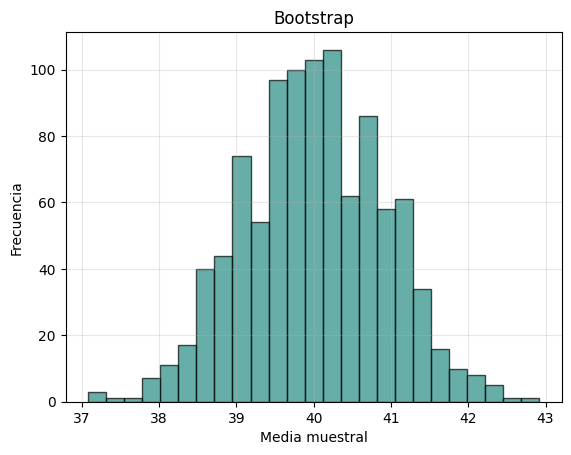

In [94]:
# Gráfica Bootstrap
plt.hist(medias_boot, bins=25, edgecolor='black', color='#278C83', alpha=0.7)
plt.xlabel('Media muestral')
plt.ylabel('Frecuencia')
plt.title('Bootstrap')
plt.grid(True, alpha=0.3)


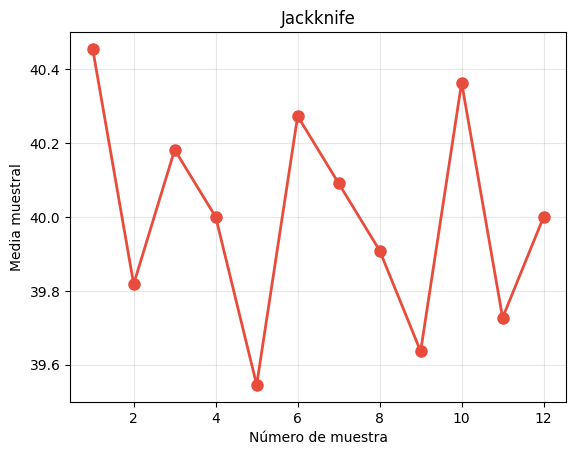

In [95]:
# Gráfica Jackknife
plt.plot(range(1, n+1), medias_jack, 'o-', color='#E74C3C', linewidth=2, markersize=8)
plt.xlabel('Número de muestra')
plt.ylabel('Media muestral')
plt.title('Jackknife')
plt.grid(True, alpha=0.3)

